<a href="https://colab.research.google.com/github/brian-stock/IT480-FA26/blob/main/Assignments/Assignment%202/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Brian Stock

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: brianstock
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:10<00:00, 37.0MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

fire_images 755
non_fire_images 244


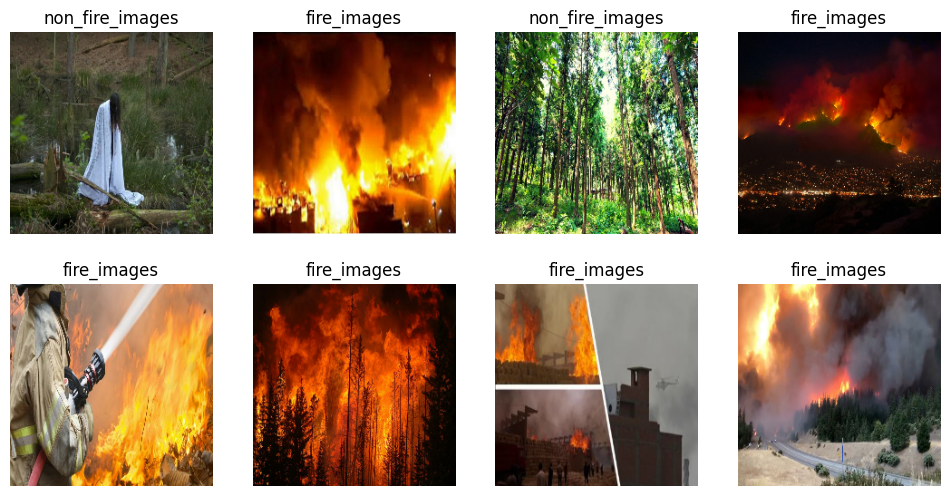

In [5]:
# Your exploration here
# Count the images in each class
for name in class_names_fire:
    folder = os.path.join(data_dir_fire, name)
    print(name, len(os.listdir(folder)))

# Show 8 sample images
images, labels = next(iter(train_raw_fire))
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names_fire[labels[i]])
    plt.axis("off")
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

There is 755 fire images and 244 non-fire images leaving about a 3:1 ratio. If the model just said fire every time it would be about %75 accurate so this leads me to belive a confusion matirx would be important. The size of the data set is not particulary large so that could play a role in score with the test set.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [6]:
# Preprocess the data here
def preprocess(images, labels):
    return preprocess_input(images), labels

train_fire = train_raw_fire.map(preprocess)
val_fire = val_raw_fire.map(preprocess)
test_fire = test_raw_fire.map(preprocess)


In [7]:
# Build your model here
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)
model_fire = Model(inputs, outputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
# Compile your model here
model_fire.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


## 1D — Train and Evaluate

In [9]:
# Train your model here
history = model_fire.fit(train_fire, validation_data=val_fire, epochs=5)


Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.7929 - loss: 0.4139 - val_accuracy: 0.9209 - val_loss: 0.2312
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9457 - loss: 0.1702 - val_accuracy: 0.9568 - val_loss: 0.1537
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9729 - loss: 0.1123 - val_accuracy: 0.9712 - val_loss: 0.1011
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9786 - loss: 0.0895 - val_accuracy: 0.9784 - val_loss: 0.0845
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9829 - loss: 0.0760 - val_accuracy: 0.9928 - val_loss: 0.0672


In [10]:
# Report validation and test accuracy here
val_loss, val_acc = model_fire.evaluate(val_fire)
test_loss, test_acc = model_fire.evaluate(test_fire)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)


5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 859ms/step - accuracy: 0.9712 - loss: 0.0855
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9812 - loss: 0.0845
Validation accuracy: 0.971222996711731
Test accuracy: 0.981249988079071


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


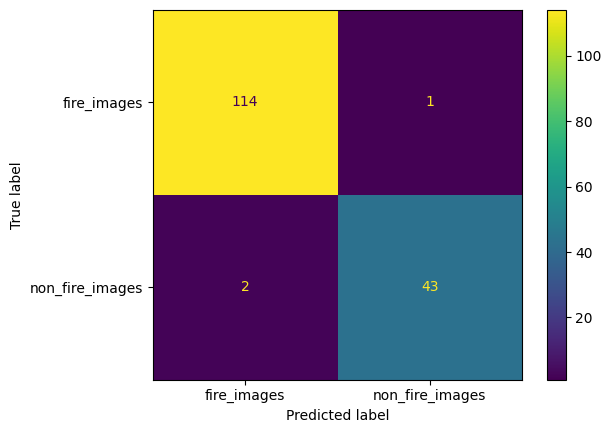

In [11]:
# Build your confusion matrix here
y_true = []
y_pred = []

for images, labels in test_fire:
    probs = model_fire.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((probs > 0.5).astype(int).ravel())

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names_fire).plot()
plt.show()


*Your answer:* Fire is class 0 so a false negative in the top right is 1 image. The false positive is in the bottom left with 2 non fire images being classified as fire.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [12]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [13]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [14]:
# Preprocess the data here
train_sat = train_raw_sat.map(preprocess)
val_sat = val_raw_sat.map(preprocess)
test_sat = test_raw_sat.map(preprocess)


In [15]:
# Build your model here
base_model_sat = MobileNetV2(weights="imagenet", include_top=False,
                             input_shape=(224, 224, 3))
base_model_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation="softmax")(x)
model_sat = Model(inputs, outputs)


In [16]:
# Compile your model here
# Compile your model here
model_sat.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


## 2C — Train and Evaluate

In [17]:
# Train your model here
history_sat = model_sat.fit(train_sat, validation_data=val_sat, epochs=3)

Epoch 1/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 928s 2s/step - accuracy: 0.8814 - loss: 0.3638 - val_accuracy: 0.9341 - val_loss: 0.2137
Epoch 2/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 862s 1s/step - accuracy: 0.9350 - loss: 0.1938 - val_accuracy: 0.9395 - val_loss: 0.1881
Epoch 3/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 913s 2s/step - accuracy: 0.9469 - loss: 0.1582 - val_accuracy: 0.9373 - val_loss: 0.1833


In [18]:
# Report validation and test accuracy here
val_loss, val_acc = model_sat.evaluate(val_sat)
test_loss, test_acc = model_sat.evaluate(test_sat)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

127/127 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9373 - loss: 0.1846
127/127 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9318 - loss: 0.1919
Validation accuracy: 0.9373141527175903
Test accuracy: 0.9318405389785767


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

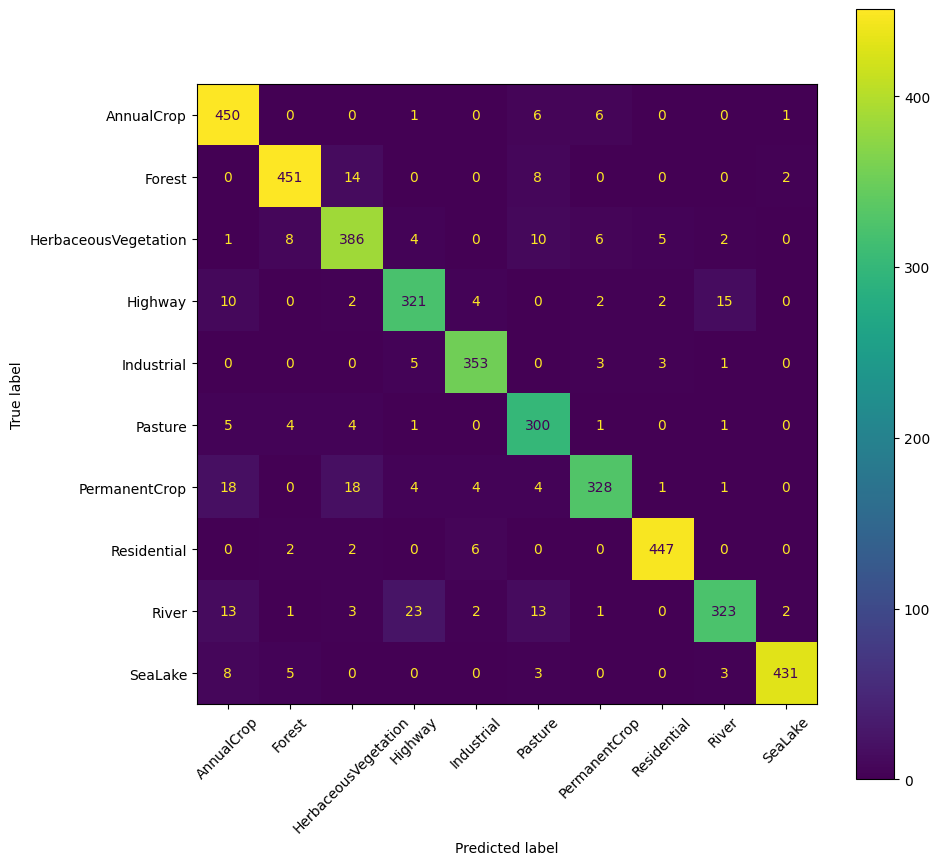

In [19]:
# Build your confusion matrix here
y_true = []
y_pred = []

for images, labels in test_sat:
    probs = model_sat.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm, display_labels=class_names_sat).plot(ax=ax, xticks_rotation=45)
plt.show()


*Your answer:* The most confused classes were River and Highway, PermanentCrop with AnnualCrop and HerbaceousVegetation, and Forest with HerbaceousVegetation. This makes sense visually as a human would likeley make similar errors.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |97.1|93.7|
| Test Accuracy |98.1|93.2|

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.

2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
Q1: Fire is the closer match to ImageNet because its images are normal ground-level photos. EuroSAT is the bigger mismatch because it is satellite imagery. My results show this, with about 98% on Fire and about 93% on EuroSAT.

Q2: Yes, unfreezing some layers of MobileNetV2 would help EuroSAT more. Its accuracy stopped improving around 93%, and it needs features specific to satellite images. Fire is already about 98%, so there is little room to improve.




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
1. The Fire dataset has about 3 times more fire images than non-fire, so always guessing "fire" would be about 75% accurate. Because of this I used the confusion matrix instead of only looking at accuracy. The dataset is also small, so the test set was only 160 images.

2. Part 1 used 1 output neuron with sigmoid and binary cross-entropy because there are only two classes. Part 2 used 10 output neurons with softmax and sparse categorical cross-entropy because there are 10 classes and the labels are integers.

3. It depends on both. The same model got about 98% on Fire but only about 93% on EuroSAT. Fire images look more like the photos MobileNetV2 was trained on, while satellite images are very different.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.